<a href="https://colab.research.google.com/github/dibendupal69724-ux/CV-documents/blob/main/Rainfall_Predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Historical Weather Data Analysis and Rainfall Prediction for Bankura, India


This project focuses on analyzing historical weather data for Bankura, India, and developing machine learning models to predict rainfall. We used the Open-Meteo Archive API to collect daily weather parameters from 2015 to 2026, including temperature, rainfall, pressure, wind speed, humidity, dew point, and cloud cover. After initial data inspection and cleaning (handling missing values, calculating average temperature, and renaming columns for clarity), an extensive Exploratory Data Analysis (EDA) was performed. This included visualizing trends of average temperature, rainfall, and pressure over time, and examining the relationship between monthly temperature and rainfall. A correlation heatmap highlighted significant relationships between various parameters where we find rainfall has strong positive correlations with humidity, cloud cover, and dew point, and a strong negative correlation with pressure. Finally, the data was standardized, and two regression models, Random Forest and Gradient Boosting, were trained and evaluated for rainfall prediction using all weather parameters as features. The models showed comparable performance, providing a foundation for future rainfall forecasting.

In [ ]:
import pandas as pd
import requests
from datetime import datetime

# Given Bankura's coordinates
bankura_latitude = 23.23
bankura_longitude = 87.07

print(f"Fetching weather data for Bankura (Latitude: {bankura_latitude}, Longitude: {bankura_longitude})")

Fetching weather data for Bankura (Latitude: 23.23, Longitude: 87.07)


In [ ]:
# Define the date range
start_date = datetime(2015, 1, 1)
end_date = datetime(2026, 5, 5)

# Open-Meteo Archive API endpoint
url = "https://archive-api.open-meteo.com/v1/archive"

# Parameters for the API request
# Selected daily parameters based on user's request and API availability
params = {
    "latitude": bankura_latitude,
    "longitude": bankura_longitude,
    "start_date": start_date.strftime('%Y-%m-%d'),
    "end_date": end_date.strftime('%Y-%m-%d'),
    "daily": "temperature_2m_max,temperature_2m_min,rain_sum,pressure_msl_mean,windspeed_10m_max,winddirection_10m_dominant,relative_humidity_2m_mean,dew_point_2m_mean,cloud_cover_mean",
    "timezone": "Asia/Kolkata"} # Setting timezone for Bankura


response = requests.get(url, params=params)

data = response.json()

    # Process the data into a pandas DataFrame
if 'daily' in data:
        daily_data = data['daily']
        df_weather = pd.DataFrame(daily_data)
        df_weather['time'] = pd.to_datetime(df_weather['time'])
        df_weather = df_weather.set_index('time')
        print("Historical weather data for Bankura:")
        display(df_weather.head())
        display(df_weather.tail())
        print(f"Data fetched from {df_weather.index.min().strftime('%Y-%m-%d')} to {df_weather.index.max().strftime('%Y-%m-%d')}")
else:
        print("No daily weather data found in the response.")
        print(data)


Historical weather data for Bankura:


,temperature_2m_max,temperature_2m_min,rain_sum,pressure_msl_mean,windspeed_10m_max,winddirection_10m_dominant,relative_humidity_2m_mean,dew_point_2m_mean,cloud_cover_mean
time,,,,,,,,,
2015-01-01,25.5,15.9,1.0,1014.6,13.5,90,79,16.0,50
2015-01-02,24.9,18.4,8.8,1015.3,12.0,82,87,18.7,88
2015-01-03,25.4,20.1,5.9,1015.0,8.7,69,92,20.4,90
2015-01-04,24.6,18.5,0.0,1014.5,12.6,332,83,18.0,73
2015-01-05,23.0,12.9,0.0,1013.9,15.0,309,72,12.9,13


,temperature_2m_max,temperature_2m_min,rain_sum,pressure_msl_mean,windspeed_10m_max,winddirection_10m_dominant,relative_humidity_2m_mean,dew_point_2m_mean,cloud_cover_mean
time,,,,,,,,,
2026-05-01,30.8,20.7,0.3,1005.7,12.4,165,76,20.4,66
2026-05-02,32.1,21.9,2.5,1003.9,11.3,128,79,21.8,13
2026-05-03,32.1,22.6,6.3,1005.6,12.3,104,78,22.9,45
2026-05-04,33.5,22.6,8.5,1007.9,20.2,111,78,23.1,55
2026-05-05,30.0,22.6,4.8,1009.5,15.9,132,83,22.1,70


Data fetched from 2015-01-01 to 2026-05-05


Explanation of each column in df_weather DataFrame:

Time: This is the date for which the weather data is recorded, in YYYY-MM-DD format.

Temperature_2m_max: The maximum air temperature at 2 meters above ground level for that day, measured in °C (degrees Celsius).

Temperature_2m_min: The minimum air temperature at 2 meters above ground level for that day, measured in °C (degrees Celsius).

Rain_sum: The total accumulated rainfall for the day, measured in mm (millimeters).

Pressure_msl_mean: The mean sea level air pressure for the day, measured in hPa (hectopascals).

Windspeed_10m_max: The maximum wind speed at 10 meters above ground level for that day, measured in km/h (kilometers per hour).

Winddirection_10m_dominant: The dominant wind direction at 10 meters above ground level for that day, measured in ° (degrees) (0° is North, 90° is East, 180° is South, 270° is West).

Relative_humidity_2m_mean: The mean relative humidity at 2 meters above ground level for the day, measured in % (percent).

Dew_point_2m_mean: The mean dew point temperature at 2 meters above ground level for the day, measured in °C (degrees Celsius).

Cloud_cover_mean: The mean cloud cover for the day, measured in % (percent).

In [ ]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4143 entries, 2015-01-01 to 2026-05-05
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   temperature_2m_max          4143 non-null   float64
 1   temperature_2m_min          4143 non-null   float64
 2   rain_sum                    4143 non-null   float64
 3   pressure_msl_mean           4143 non-null   float64
 4   windspeed_10m_max           4143 non-null   float64
 5   winddirection_10m_dominant  4143 non-null   int64  
 6   relative_humidity_2m_mean   4143 non-null   int64  
 7   dew_point_2m_mean           4143 non-null   float64
 8   cloud_cover_mean            4143 non-null   int64  
dtypes: float64(6), int64(3)
memory usage: 323.7 KB


In [ ]:
# Check for missing values in each column
missing_values = df_weather.isnull().sum()
print("Missing values per column:")
display(missing_values)

Missing values per column:


,0
temperature_2m_max,0
temperature_2m_min,0
rain_sum,0
pressure_msl_mean,0
windspeed_10m_max,0
winddirection_10m_dominant,0
relative_humidity_2m_mean,0
dew_point_2m_mean,0
cloud_cover_mean,0


In [ ]:
# Calculating the average temperature and adding that column to the dataframe
df_weather['average_temperature'] = (df_weather['temperature_2m_max'] + df_weather['temperature_2m_min']) / 2

print("DataFrame with 'average_temperature' column:")
df_weather.head()

DataFrame with 'average_temperature' column:


,temperature_2m_max,temperature_2m_min,rain_sum,pressure_msl_mean,windspeed_10m_max,winddirection_10m_dominant,relative_humidity_2m_mean,dew_point_2m_mean,cloud_cover_mean,average_temperature
time,,,,,,,,,,
2015-01-01,25.5,15.9,1.0,1014.6,13.5,90,79,16.0,50,20.70
2015-01-02,24.9,18.4,8.8,1015.3,12.0,82,87,18.7,88,21.65
2015-01-03,25.4,20.1,5.9,1015.0,8.7,69,92,20.4,90,22.75
2015-01-04,24.6,18.5,0.0,1014.5,12.6,332,83,18.0,73,21.55
2015-01-05,23.0,12.9,0.0,1013.9,15.0,309,72,12.9,13,17.95


In [ ]:
# Droping the original min and max temperature columns
df_weather = df_weather.drop(columns=['temperature_2m_max', 'temperature_2m_min'])

# Renaming the columns to their short forms
df_weather = df_weather.rename(columns={
    'rain_sum': 'rain',
    'pressure_msl_mean': 'pressure',
    'windspeed_10m_max': 'wind_speed',
    'winddirection_10m_dominant': 'wind_dir',
    'relative_humidity_2m_mean': 'humidity',
    'dew_point_2m_mean': 'dew_point',
    'cloud_cover_mean': 'cloud_cover',
    'average_temperature': 'avg_temp'
})

print("DataFrame after droping and renaming columns:")
df_weather.head()

DataFrame after droping and renaming columns:


,rain,pressure,wind_speed,wind_dir,humidity,dew_point,cloud_cover,avg_temp
time,,,,,,,,
2015-01-01,1.0,1014.6,13.5,90,79,16.0,50,20.70
2015-01-02,8.8,1015.3,12.0,82,87,18.7,88,21.65
2015-01-03,5.9,1015.0,8.7,69,92,20.4,90,22.75
2015-01-04,0.0,1014.5,12.6,332,83,18.0,73,21.55
2015-01-05,0.0,1013.9,15.0,309,72,12.9,13,17.95


In [ ]:
print("Summary statistics for df_weather:")
df_weather.describe()

Summary statistics for df_weather:


,rain,pressure,wind_speed,wind_dir,humidity,dew_point,cloud_cover,avg_temp
count,4143.000000,4143.000000,4143.000000,4143.000000,4143.000000,4143.000000,4143.000000,4143.000000
mean,4.321892,1008.023051,13.425585,205.113686,71.895004,19.292276,46.366160,26.148383
std,9.240658,6.240348,4.660601,105.682859,14.747687,6.020892,37.207405,4.657480
min,0.000000,990.800000,5.200000,0.000000,18.000000,2.500000,0.000000,14.000000
25%,0.000000,1002.900000,10.000000,126.000000,63.000000,13.900000,10.000000,22.600000
50%,0.100000,1008.000000,12.300000,193.000000,74.000000,20.800000,39.000000,27.550000
75%,5.000000,1013.500000,15.900000,319.000000,84.000000,25.000000,86.000000,29.225000
max,125.700000,1020.700000,55.600000,360.000000,96.000000,28.000000,100.000000,37.100000


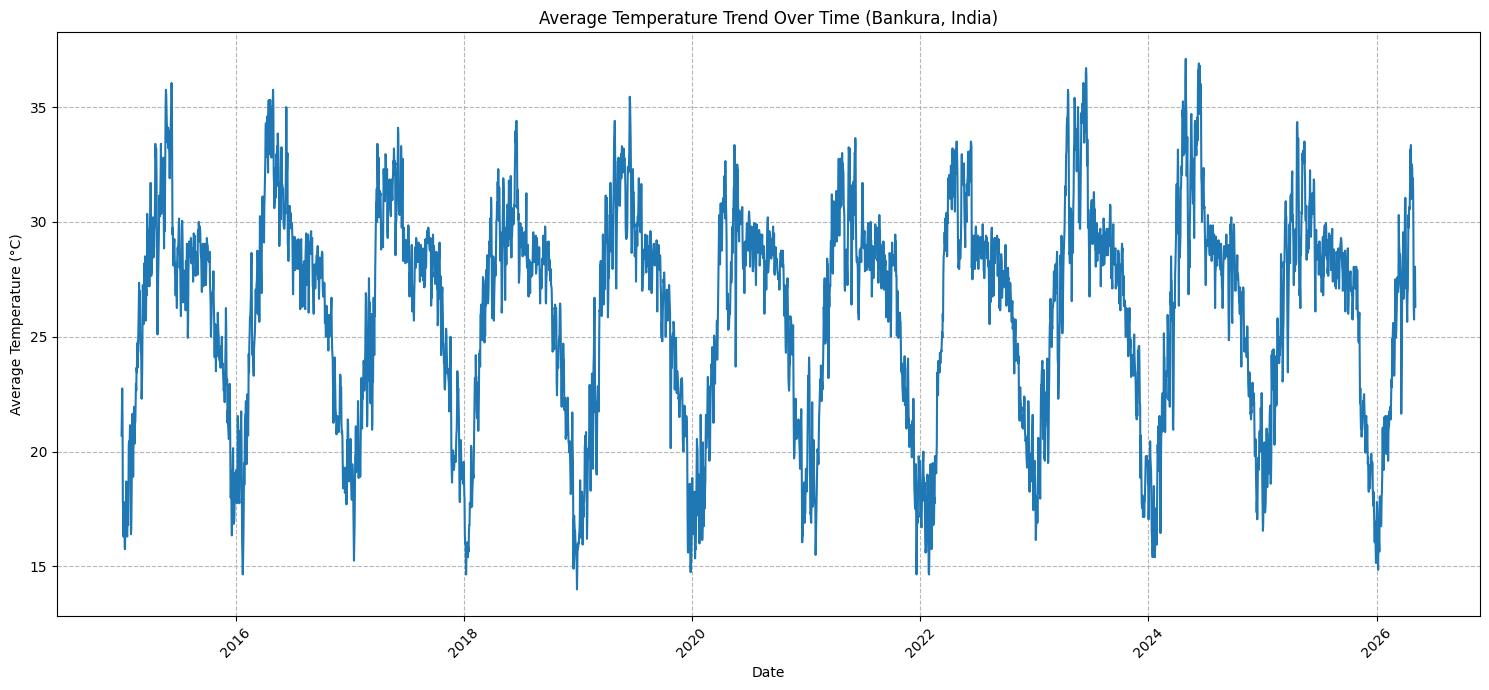

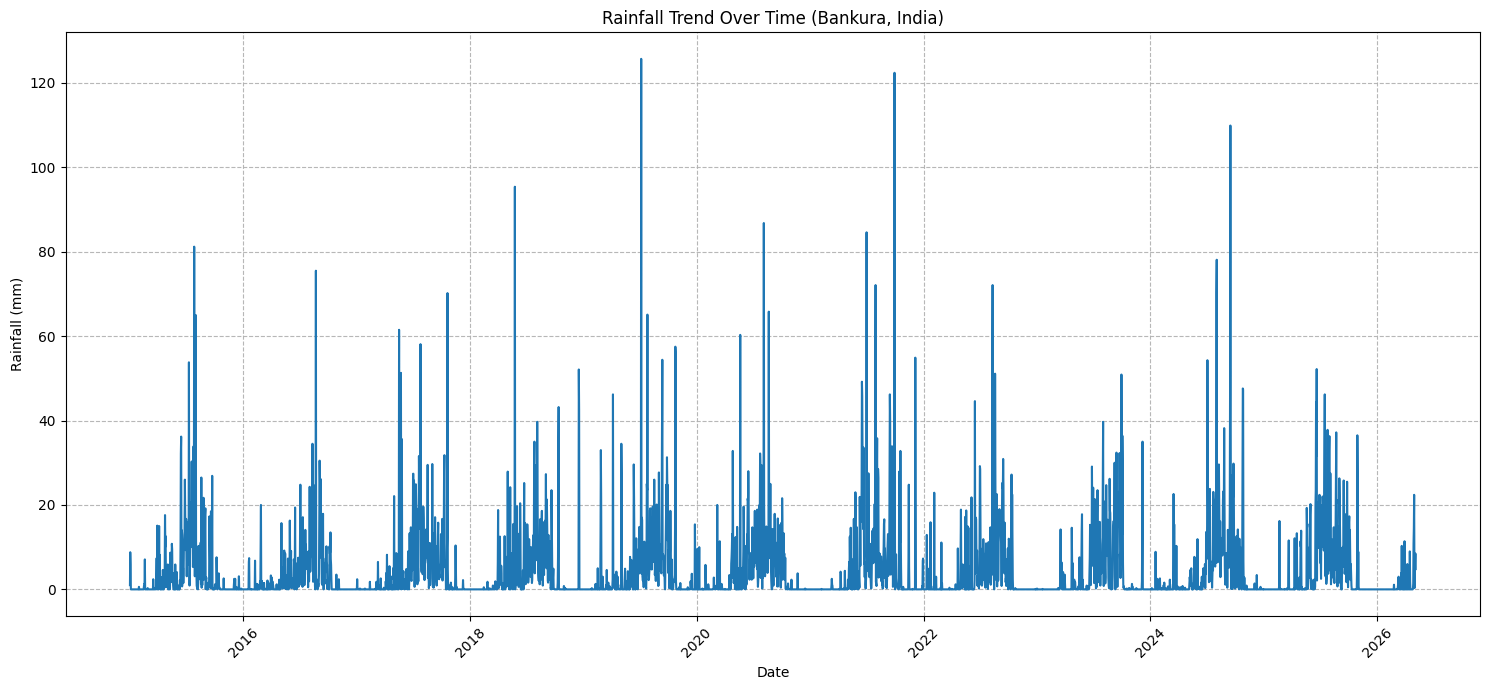

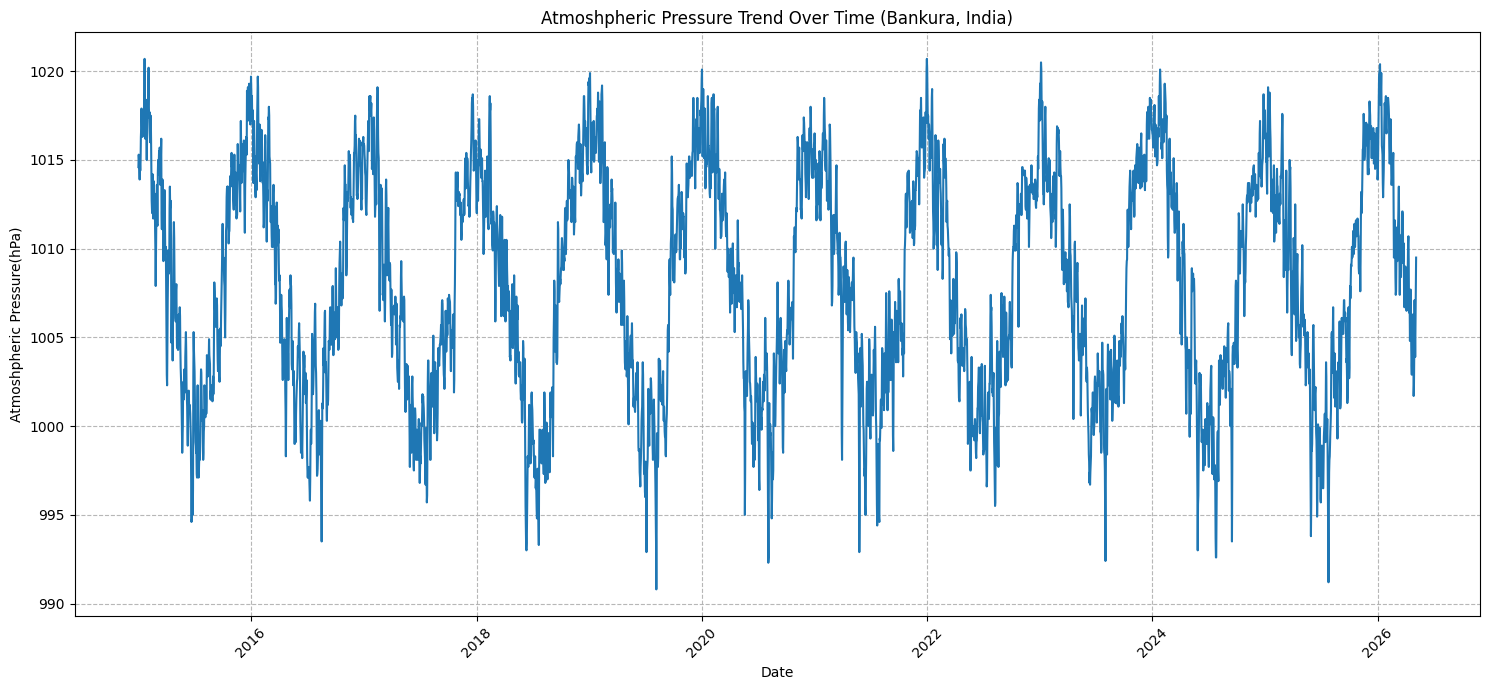

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = ['avg_temp', 'rain','pressure']
ylabels = {'avg_temp': 'Average Temperature (°C)', 'rain': 'Rainfall (mm)','pressure': 'Atmoshpheric Pressure(hPa)'}
titles = {'avg_temp': 'Average Temperature Trend Over Time (Bankura, India)', 'rain': 'Rainfall Trend Over Time (Bankura, India)','pressure': 'Atmoshpheric Pressure Trend Over Time (Bankura, India)'}

for i in columns:
    plt.figure(figsize=(15, 7))
    sns.lineplot(x=df_weather.index, y=i, data=df_weather)
    plt.title(titles[i])
    plt.xlabel('Date')
    plt.ylabel(ylabels[i])
    plt.grid(True, linestyle='--', alpha=0.9)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

First plot shows the trend of average temperature in Bankura, India, from 2015 to 2026 where we observe the seasonal variations in temperature over the years as well as rising trend of increasing temperature which peaks in 2024.




Second plot displays the daily rainfall over the years for Bankura. You can observe periods of higher and lower rainfall, which varies due to monsoon seasons and dry seasons. 2016 and 2018 seems to be the driest yrs for rainfall.

Third plot displays the pressure variation over the years for Bankura. We can clearly see the relationship between this three parameters, where low pressure in high temp summer brings monsoon rainfall and then it retreats due to high pressure zone created over Indian landmass and then the winter prevails over that time of year stretching the dry periods and leading to next cycle.

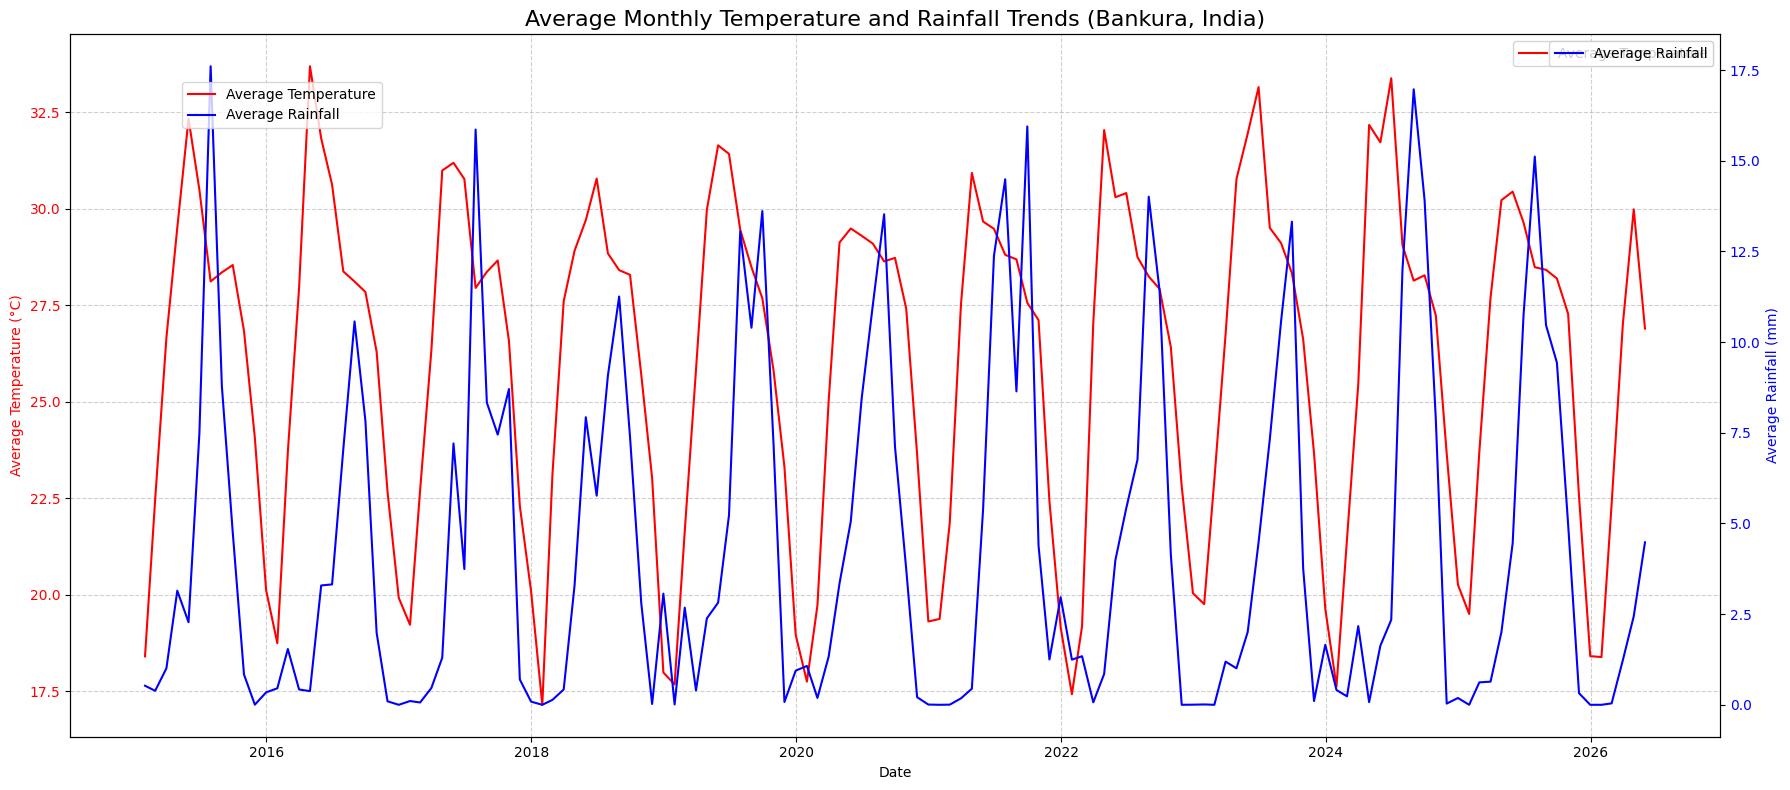

In [ ]:
# Resample data to monthly averages
df_monthly = df_weather[['avg_temp', 'rain']].resample('ME').mean()

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(18, 8))

# Plot Average Temperature on the primary y-axis (ax1)
sns.lineplot(x=df_monthly.index, y='avg_temp', data=df_monthly, ax=ax1, color='red', label='Average Temperature')
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Temperature (°C)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a secondary y-axis for Rainfall
ax2 = ax1.twinx()
sns.lineplot(x=df_monthly.index, y='rain', data=df_monthly, ax=ax2, color='blue', label='Average Rainfall')
ax2.set_ylabel('Average Rainfall (mm)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Set title and legends
plt.title('Average Monthly Temperature and Rainfall Trends (Bankura, India)', fontsize=16)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This plot shows the average monthly temperature and rainfall on a single graph. with red line representing the average temperature on the left y-axis, and the blue line representing the average rainfall on the right y-axis. This visualization helps in understanding the relationship between temperature and rainfall patterns throughout the year like after heated summer creates low pressure area and so monsoon enters India.This can be visualized better with heatmap in next part.

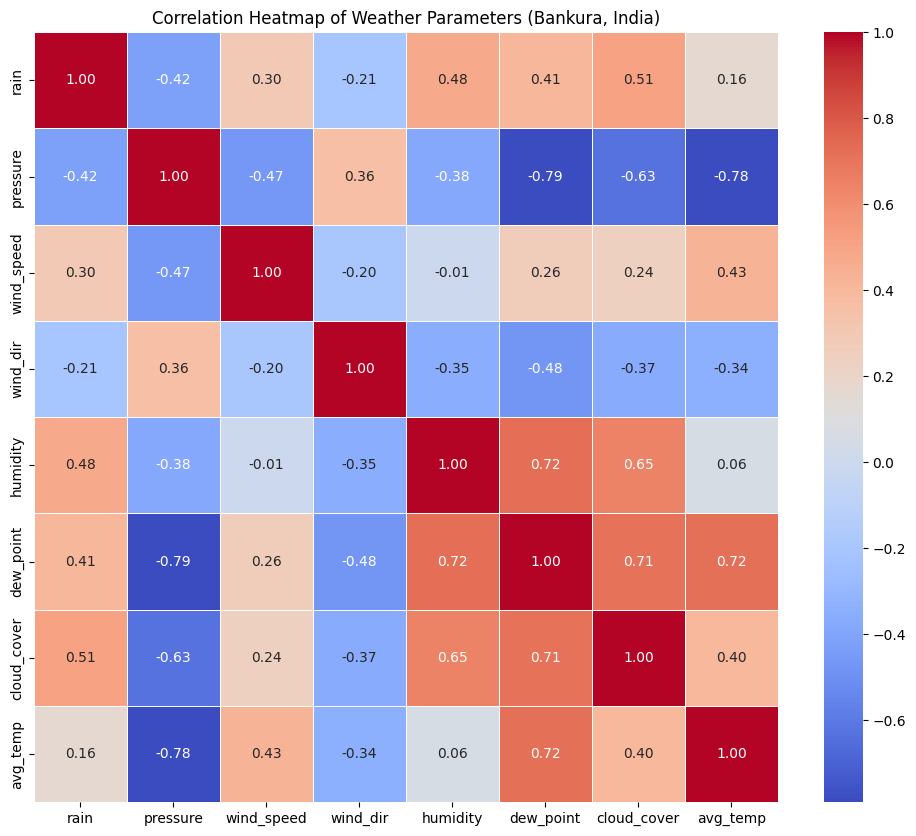

In [ ]:
# Calculating the correlation matrix
correlation_matrix = df_weather.corr()

# Creating the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Weather Parameters (Bankura, India)')
plt.show()

This heatmap visualizes the Pearson correlation coefficients between all the weather parameters. The values range from -1 to 1, where:
-   1 indicates a strong positive correlation (as one parameter increases, the other also increases).
-   -1 indicates a strong negative correlation (as one parameter increases, the other decreases).
-   0 indicates no linear correlation.

The color intensity and the square values help in quickly identifying strong relationships.

Based on the correlation_matrix:

Humidity  has a strong positive correlation with rain (0.48).
Cloud Cover  also shows a positive correlation with rain (0.51).
Dew Point  has a positive correlation with rain (0.41).
Therefore, Cloud Cover appears to have the strongest positive correlation with rain among all the parameters.

Also Pressure  has the strongest negative correlation with rain (-0.42).
Wind Direction  is next with a negative correlation of (-0.21).

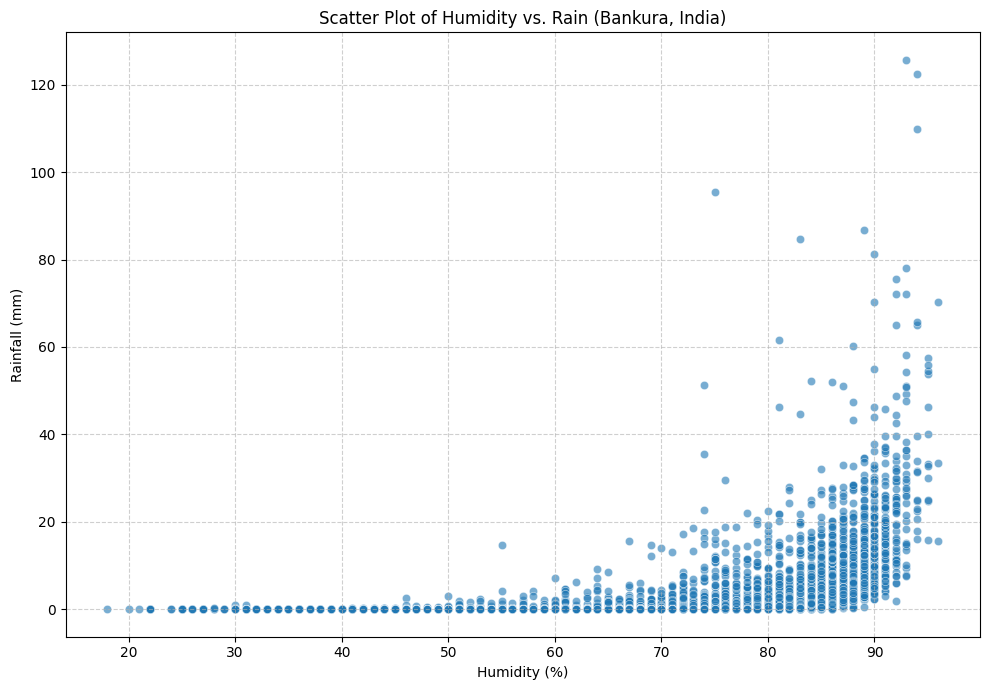

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='humidity', y='rain', data=df_weather, alpha=0.6)
plt.title('Scatter Plot of Humidity vs. Rain (Bankura, India)')
plt.xlabel('Humidity (%)')
plt.ylabel('Rainfall (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

This scatter plot helps visualize the relationship between humidity and rainfall. Each point represents a day's humidity and rainfall. A cluster of points with high humidity and high rainfall would suggest a positive correlation, which aligns with our previous observation from the correlation matrix.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_weather)
scaled_df = pd.DataFrame(scaled_data,
                         columns=df_weather.columns)
print(scaled_df.head())

       rain  pressure  wind_speed  wind_dir  humidity  dew_point  cloud_cover  \
0 -0.359530  1.054067    0.015969 -1.089369  0.481828  -0.546875     0.097676   
1  0.484668  1.166253   -0.305917 -1.165076  1.024352  -0.098382     1.119102   
2  0.170799  1.118173   -1.014066 -1.288100  1.363429   0.184002     1.172861   
3 -0.467760  1.038040   -0.177163  1.200778  0.753090  -0.214658     0.715907   
4 -0.467760  0.941880    0.337854  0.983119  0.007120  -1.061811    -0.896870   

   avg_temp  
0 -1.169955  
1 -0.965957  
2 -0.729749  
3 -0.987431  
4 -1.760474  


Standardization scales features by subtracting the mean and dividing by the standard deviation. This transforms the data so that features have zero mean and unit variance, which helps many machine learning models perform better as the scales ar enow similiar.

Model Comparison Using All Weather Parameters:


,Model,MAE,R2 Score
0,Random Forest,0.257297,0.635940
1,Gradient Boosting,0.258486,0.648686


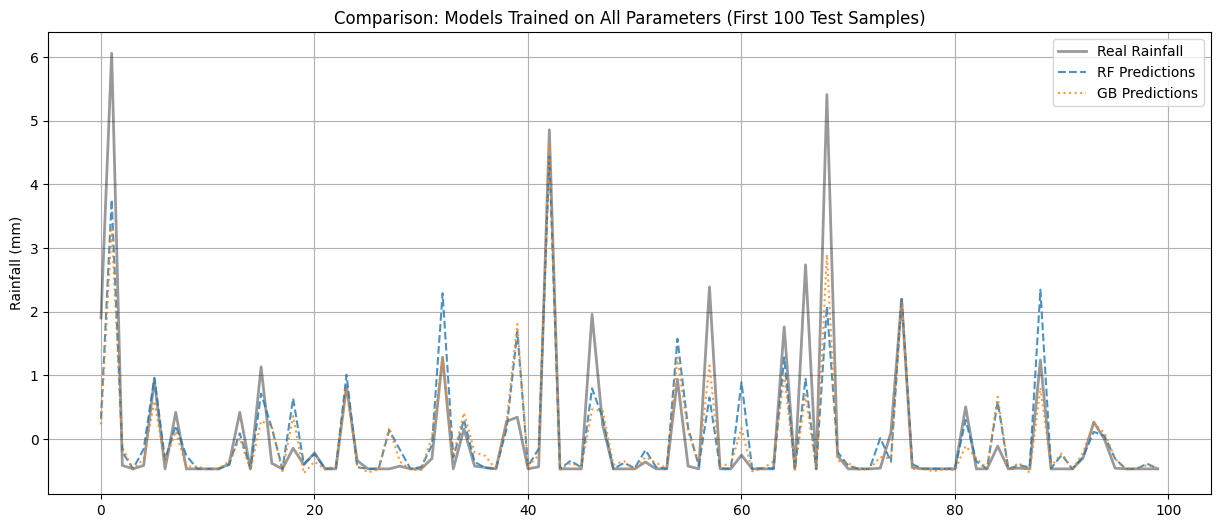

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define Features (ALL weather parameters) and Target
features_all = ['pressure', 'wind_speed', 'wind_dir', 'humidity', 'dew_point', 'cloud_cover', 'avg_temp']
X_all = scaled_df[features_all]
y_all = scaled_df['rain']

# 2. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

# 3. Fit Models
rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
gb_final = GradientBoostingRegressor(n_estimators=100, random_state=42)

rf_final.fit(X_train, y_train)
gb_final.fit(X_train, y_train)

# 4. Predictions
y_pred_rf = rf_final.predict(X_test)
y_pred_gb = gb_final.predict(X_test)

# 5. Evaluate and Compare Accuracy
metrics = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'MAE': [mean_absolute_error(y_test, y_pred_rf), mean_absolute_error(y_test, y_pred_gb)],
    'R2 Score': [r2_score(y_test, y_pred_rf), r2_score(y_test, y_pred_gb)]
})

print("Model Comparison Using All Weather Parameters:")
display(metrics)

# 6. Visualization: Predictions vs Real Rainfall
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:100], label='Real Rainfall', color='black', alpha=0.4, linewidth=2)
plt.plot(y_pred_rf[:100], label='RF Predictions', linestyle='--', alpha=0.8)
plt.plot(y_pred_gb[:100], label='GB Predictions', linestyle=':', alpha=0.8)
plt.title('Comparison: Models Trained on All Parameters (First 100 Test Samples)')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

So both models predict near about same.Using this trained model we can try predicting the amount of rainfall based on new weather parameters data